#MisCancionesV2

In [ ]:
#Primero importamos librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [ ]:
datos = pd.read_excel("/content/drive/MyDrive/Introducción BI/Bases de Datos/MisCancionesV2.xls",sheet_name=None, header=0)

In [ ]:
datos.keys() #retornar las claves del diccionario, en este

dict_keys(['Artistas', 'Canciones', 'Álbumes', 'Géneros'])

In [ ]:
datos['Canciones']

,identificador,título,duración,género,idioma,artista principal,álbum original
0,10001,La tierra del olvido,00:04:25,1,español,50001,900001.0
1,10002,Ojos así,00:03:57,3,español,50003,900002.0
2,10003,Mi gente,00:03:05,4,español,50005,NaN
3,10004,Ambiente,00:04:08,4,español,50005,900004.0
4,10005,Cali pachanguero,00:04:51,2,español,50002,900005.0
5,10006,La creciente,00:03:04,1,español,50004,900006.0
6,10007,Sueños de conquista,00:04:02,1,español,50004,900008.0
7,10009,Carito,00:03:39,3,español,50001,900009.0
8,10011,Una aventura,00:05:16,2,español,50002,900011.0
9,10012,Ginza,00:04:39,4,español,50005,NaN


In [ ]:
#Primero se lee o se crea la base de datos
conexion = sqlite3.connect("MusicaColombiana.db")
cursor = conexion.cursor()

In [ ]:
#dado que se tienen varias, tablas, usaremos un ciclo para
#pasar la información desde el diccionario datos hasta la
#base de datos creada

for hoja, datos in datos.items():
  datos.to_sql(hoja, conexion, if_exists='replace', index=False)

In [ ]:
#Confirmamos los cmabios ejecutados en la base de datos
conexion.commit()

In [ ]:
#Para visualizar los nombres de todas las tablas que tiene la base de datos

consulta = '''SELECT *
            FROM Artistas '''

#Ejecutamos la consulta
cursor.execute(consulta)
#Traemos el resultado de la consulta
artista = cursor.fetchall()
for fila in artista:
   print(fila)


(50001, 'Carlos Vives', 1986, None, 'Solista', 1)
(50002, 'Niche', 1979, None, 'Grupo', 2)
(50003, 'Shakira', 1990, None, 'Solista', 3)
(50004, 'Binomio de Oro de América', 1976, None, 'Grupo', 1)
(50005, 'J Balvin', 2006, None, 'Solista', 4)


In [ ]:
#Para convertir el resultado de la consulta en un DataFrame de pandas
columnas = [descripcion[0] for descripcion in cursor.description]
df_artistas = pd.DataFrame(artista, columns=columnas)
df_artistas

,identificador,nombre,año de lanzamiento,año de retiro,tipo,género principal
0,50001,Carlos Vives,1986,None,Solista,1
1,50002,Niche,1979,None,Grupo,2
2,50003,Shakira,1990,None,Solista,3
3,50004,Binomio de Oro de América,1976,None,Grupo,1
4,50005,J Balvin,2006,None,Solista,4


In [ ]:
#Para mirar la información de todas las columnas
consulta = '''PRAGMA table_info(Artistas)'''
#Ejecutamos la consulta
cursor.execute(consulta)
#Traemos el resultado de la consulta
resultados = cursor.fetchall()
for resultado in resultados:
   print(resultado)

(0, 'identificador', 'INTEGER', 0, None, 0)
(1, 'nombre', 'TEXT', 0, None, 0)
(2, 'año de lanzamiento', 'INTEGER', 0, None, 0)
(3, 'año de retiro', 'REAL', 0, None, 0)
(4, 'tipo', 'TEXT', 0, None, 0)
(5, 'género principal', 'INTEGER', 0, None, 0)


##Ejemplos de Consultas

1. Seleccionar el título, la fecha de lanzamiento, el sello discográfico de la tabla Álbumes y ordenar el resultado por título de manera ascendente.

In [ ]:
consulta = '''SELECT título AS álbum,
                      "fecha de lanzamiento" as lanzamiento,
                      "sello discográfico" as sello
            FROM Álbumes
            ORDER BY título ASC'''
#Ejecutamos la consulta
cursor.execute(consulta)
#Traemos el resultado de la consulta
resultados = cursor.fetchall()
for resultado in resultados:
   print(resultado)

('Cielo de tambores', '1990-12-20 00:00:00', 'Codiscos')
('Déjame entrar', '2001-11-06 00:00:00', 'EMI Latin')
('El binomio de oro', '1976-11-03 00:00:00', 'Codiscos')
('La tierra del olvido', '1995-07-25 00:00:00', 'EMI Latin')
('No hay quinto malo', None, 'Internacional Records')
('Por lo alto', '1976-11-02 00:00:00', 'Codiscos')
('Vibras', '2018-05-25 00:00:00', 'Universal')
('¿Dónde están los ladrones?', '1998-09-29 00:00:00', 'Sony Music')


In [ ]:
columnas = [descripcion[0] for descripcion in cursor.description]
df_albumes = pd.DataFrame(resultados, columns=columnas)
df_albumes

,álbum,lanzamiento,sello
0,Cielo de tambores,1990-12-20 00:00:00,Codiscos
1,Déjame entrar,2001-11-06 00:00:00,EMI Latin
2,El binomio de oro,1976-11-03 00:00:00,Codiscos
3,La tierra del olvido,1995-07-25 00:00:00,EMI Latin
4,No hay quinto malo,None,Internacional Records
5,Por lo alto,1976-11-02 00:00:00,Codiscos
6,Vibras,2018-05-25 00:00:00,Universal
7,¿Dónde están los ladrones?,1998-09-29 00:00:00,Sony Music


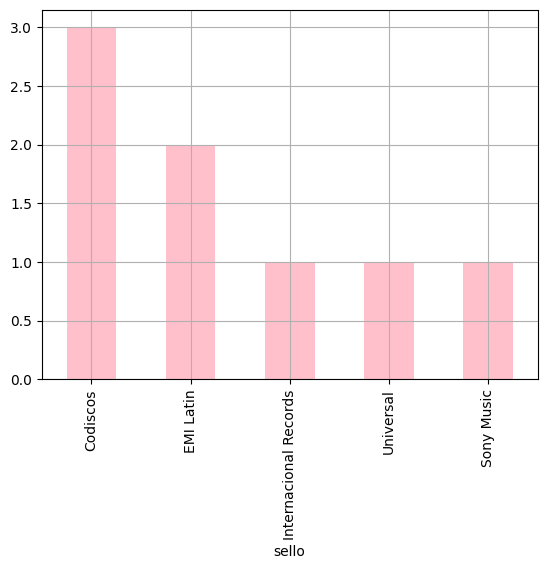

In [ ]:
#Generamos un gráfico para conocer a distribución de los sellos discográficos

frecuencias = df_albumes['sello'].value_counts()
frecuencias.plot(kind='bar', color = "pink")
plt.grid()

In [ ]:
#Cerramos conexión con la base de datos
conexion.close()

#MisCancionesV3

In [ ]:
#Creamos la conexión a la base de datos si existe, en caso contrario, se genera la base de datos
conexion = sqlite3.connect("MisCancionesV3.db")
cursor = conexion.cursor()

In [ ]:
#Abrimos el archivo de SQL para ejecutar las consultas
with open("/content/drive/MyDrive/Introducción BI/Bases de Datos/Creación MisCanciones V3.sql", "r") as archivo:
  sql_script = archivo.read()

#ejecutamos las consultas
cursor.executescript(sql_script)

#confirmamos los cambios
conexion.commit()

In [ ]:
#Visualizamos las tablas de la nueva base de datos
consulta = '''SELECT name
            FROM sqlite_master
            WHERE type='table' '''
#Ejecutamos la consulta
cursor.execute(consulta)
#Traemos el resultado de la consulta
print(cursor.fetchall())

[('Géneros',), ('Álbumes',), ('Usuarios',), ('Intérpretes',), ('Canciones',), ('Calificaciones',), ('Reproducciones',), ('ListasReproducción',), ('CancionesLista',)]


In [ ]:
#Nombre completo y fecha de registro de todos los usuarios
consulta1 = '''SELECT nombres||' '||apellidos,
           "fechaRegistro"
            FROM Usuarios '''
#Ejecutamos la consulta
cursor.execute(consulta1)
#Traemos el resultado de la consulta
resultados = cursor.fetchall()
for resultado in resultados:
   print(resultado)

('Alexander Buenahora', '01/01/2020')
('Ernesto Gonzalez', '20/12/2019')
('René Descartes', '13/07/2021')
('Fatme Issa', '30/01/2021')
('Baruch  Spinoza', '13/06/2020')
('Marie Curie ', '12/05/2018')
('Ana Frank', '24/02/2017')
('Piedad Bonnett', '17/06/2020')
('Jean-Jacques Rousseau', '12/09/2020')
('Mario Bunge', '08/11/2020')


In [ ]:
#Para que las diversas funciones de SQLite que operan sobre las fechas puedan funcionar, vamos a cambiar el formato original de las columnas
# de fecha en la tabla de Usuarios (d/m/y -> y-m-d).
#Para ello usamos la función UPDATE

consulta = '''UPDATE Usuarios
            SET fechaRegistro = substr(fechaRegistro,7,4)||'-'||substr(fechaRegistro,4,2)||'-'||substr(fechaRegistro,1,2)'''
#Ejecutamos la consulta
cursor.execute(consulta)
#Confirmamos los cambios
conexion.commit()

In [ ]:
#Realizamos la misma operación sobre la columna de fechaNacimiento

consulta = '''UPDATE Usuarios
            SET fechaNacimiento = substr(fechaNacimiento,7,4)||'-'||substr(fechaNacimiento,4,2)||'-'||substr(fechaNacimiento,1,2)'''
#Ejecutamos la consulta
cursor.execute(consulta)
#Confirmamos los cambios
conexion.commit()

In [ ]:
cursor.execute('SELECT * FROM Usuarios')
resultados = cursor.fetchall()
for resultado in resultados:
  print(resultado)

(1, 'alex@gmail.com', '81dc9bdb52d04dc20036dbd8313ed055', 'Alexander', 'Buenahora', 'M', '1988-08-27', 'Colombia', 'España', 'Español', '2020-01-01')
(2, 'ernesto@hotmail.com', '81b073de9370ea873f548e31b8adc081', 'Ernesto', 'Gonzalez', 'M', '1980-03-23', 'Venezuela', 'Colombia', 'Español', '2019-12-20')
(3, 'rene.metodo@gmail.com', 'def7924e3199be5e18060bb3e1d547a7', 'René', 'Descartes', 'F', '2000-01-01', 'Francia', 'Francia', 'Francés', '2021-07-13')
(4, 'fatima@yahoo.com', '6562c5c1f33db6e05a082a88cddab5ea', 'Fatme', 'Issa', 'F', '1976-07-11', 'Ecuador', 'Ecuador', 'Español', '2021-01-30')
(5, 'panteismo@gmail.com', '674f3c2c1a8a6f90461e8a66fb5550ba', 'Baruch ', 'Spinoza', 'M', '1970-06-06', 'Holanda', 'Portugal', 'Holandés', '2020-06-13')
(6, 'marie.curie@gmail.com', '46d045ff5190f6ea93739da6c0aa19bc', 'Marie', 'Curie ', 'F', '1992-09-06', 'Francia', 'Venezuela', 'Francés', '2018-05-12')
(7, 'ana.frank@hotmail.com', 'cdaeb1282d614772beb1e74c192bebda', 'Ana', 'Frank', 'F', '1998-06-

In [ ]:
#¿Cuál es el e-mail, sexo, país de residencia, edad actual y edad al momento de registrarse en la plataforma de Streaming

consulta = '''SELECT email,
              sexo,
           "paísResidencia",
            strftime('%Y', 'now') - strftime('%Y', fechaNacimiento) AS edadActual,
            strftime('%Y', fechaRegistro) - strftime('%Y', fechaNacimiento) AS edadRegistro
            FROM Usuarios; '''
#Ejecutamos la consulta
cursor.execute(consulta)
#Traemos el resultado de la consulta
resultados = cursor.fetchall()
for resultado in resultados:
  print(resultado)

('alex@gmail.com', 'M', 'España', 36, 32)
('ernesto@hotmail.com', 'M', 'Colombia', 44, 39)
('rene.metodo@gmail.com', 'F', 'Francia', 24, 21)
('fatima@yahoo.com', 'F', 'Ecuador', 48, 45)
('panteismo@gmail.com', 'M', 'Portugal', 54, 50)
('marie.curie@gmail.com', 'F', 'Venezuela', 32, 26)
('ana.frank@hotmail.com', 'F', 'Alemania', 26, 19)
('piedad.bonnett@gmail.com', 'F', 'Colombia', 73, 69)
('elcontratosocial@yahoo.com', 'M', 'Francia', 37, 33)
('laciencia.bunge@hotmail.com', 'M', 'Cánada', 105, 101)


## Funciones Agregadas
Son aquelllas que se usan para resumir los datos

In [ ]:
#Cuantas canciones clasificadas en el genero 4 se tienen almacenas en la colección?
consulta = '''SELECT COUNT(*)
FROM Canciones
WHERE idGénero = 4 '''
#Ejecutamos la consulta
cursor.execute(consulta)
#Traemos el resultado de la consulta
resultados = cursor.fetchall()
for resultado in resultados:
  print(resultado)

(4,)


In [ ]:
#Cuántos álbunes tienen canciones almacenadas en la colección de estén clasificadas en el género 3 o en el género 6
consulta = '''SELECT COUNT(*)
FROM Canciones
WHERE idGénero in (3,6)'''
#Ejecutamos la consulta
cursor.execute(consulta)
#Traemos el resultado de la consulta
resultados = cursor.fetchall()
for resultado in resultados:
  print(resultado)

(6,)


In [ ]:
#Cuánto tiempo tomaría reproducir de forma continua todas las canciones del álbum con id 15?
consulta = '''SELECT SUM(substr(duración,1,2)*3600+substr(duración,4,2)*60+substr(duración,7,2))/3600,
    (SUM(substr(duración,1,2)*3600+substr(duración,4,2)*60+substr(duración,7,2))%3600)/60,
    SUM(substr(duración,1,2)*3600+substr(duración,4,2)*60+substr(duración,7,2))%60 AS duraciónTotal
  FROM Canciones
  WHERE IdÁlbumOriginal = 15'''
#Ejecutamos la consulta
cursor.execute(consulta)
#Traemos el resultado de la consulta
resultados = cursor.fetchall()
for resultado in resultados:
  print(resultado)

(0, 6, 32)
